In [25]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
import operator
load_dotenv()

True

In [26]:
class ApproveTweet(BaseModel):
    action: Literal['approve', 'reject'] = Field(description="The action to take on the tweet")
    feedback: str = Field(description="Feedback for the user if the tweet is rejected")

In [27]:
model = ChatGroq(model="llama-3.3-70b-versatile")
structured_model = model.with_structured_output(ApproveTweet)

In [28]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    action: str
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    iteration: int
    max_iterations: int

In [29]:
def generate_tweet(state: TweetState) -> dict:
    messages = [
        SystemMessage(content='You are a witty comedian who writes short, funny tweets.'),
        HumanMessage(content=f"Write a tweet about {state['topic']}.")
    ]

    response = model.invoke(messages)
    return {"tweet": response.content, "tweet_history": [response.content]}

In [30]:
def evaluate_tweet(state: TweetState) -> dict:
    messages = [
        SystemMessage(content='You are a strict content moderator for a social media platform.'),
        HumanMessage(content=(
                            f"Evaluate this tweet: '{state['tweet']}'. "
                            "Approve only if it is under 100 characters AND funny. "
                            "Otherwise, reject. Output only: approve or reject."
                        )
                    )
    ]

    response = structured_model.invoke(messages)
    return {"action": response.action, "feedback_history": [response.feedback]}

In [31]:
def regenerate_tweet(state: TweetState) -> dict:
    messages = [
        SystemMessage(content='You are a witty comedian who writes short, funny tweets.'),
        HumanMessage(content=(
                            f"Here is the tweet you wrote: '{state['tweet']}'. "
                            f"The feedback from the content moderator was: '{state['feedback_history'][-1]}'. "
                            "Use this feedback to write a new, improved version of the tweet on the same topic."
                        )
                    )
    ]

    response = model.invoke(messages)
    current = state['iteration'] + 1 
    return {"tweet": response.content, "tweet_history": [response.content], "iteration": current}

In [32]:
def conditional_check(state: TweetState) -> Literal['regenerate_tweet', 'END']:
    if state['action'] == 'approve' or state['iteration'] >= state['max_iterations']:
        return END
    else:
        return 'regenerate_tweet'

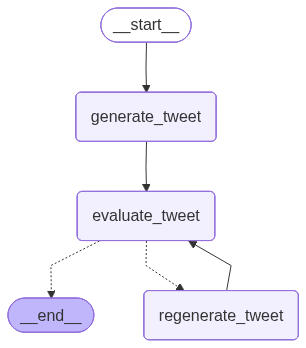

In [33]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('regenerate_tweet', regenerate_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet', conditional_check, {'regenerate_tweet': 'regenerate_tweet', END: END})
graph.add_edge('regenerate_tweet', 'evaluate_tweet')

graph.compile()

In [34]:
workflow = graph.compile()

In [35]:
initial_state = {
    "topic": "school lunches",
    "iteration": 0,
    "max_iterations": 3
}

result = workflow.invoke(initial_state)

In [36]:
result

{'topic': 'school lunches',
 'tweet': '"Mystery meat in school lunch. Chefs or lab tests? #SchoolLunch"',
 'action': 'reject',
 'tweet_history': ['"Just had a school lunch that was so bad, I\'m pretty sure the cafeteria lady hates me. I\'m starting to think the mystery meat is just a dare from the lunch ladies to see how much we\'ll eat before we turn into it #SchoolLunchStruggles"',
  'Here\'s a new version of the tweet that\'s within the character limit and hopefully funnier: "Mystery meat in school lunch today. I\'m pretty sure the cafeteria ladies are secretly scientists testing how much weird stuff we\'ll eat #SchoolLunchStruggles"',
  '"Mystery meat in school lunch. Cafeteria ladies: chefs or scientists testing our limits? #SchoolLunchStruggles"',
  '"Mystery meat in school lunch. Chefs or lab tests? #SchoolLunch"'],
 'feedback_history': ['Tweet exceeds character limit or is not funny enough.',
  'The tweet exceeds the character limit.',
  'The tweet is over 100 characters.',
  '